In [36]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from typing import Optional

In [37]:
# Get data into dataframe
df = pd.read_csv('../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to only have temperature, salinity and dissolved oxygen
df_TSO = df.copy()
df_TSO = df_TSO[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]','Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]']]
df_TSO = df_TSO.dropna()

In [38]:
def uniform_geographic_sample(
    df: pd.DataFrame,
    n_samples: int,
    lat_col: str = 'latitude',
    lon_col: str = 'longitude',
    n_grid_cells: int = 50,
    random_state: Optional[int] = None) -> pd.DataFrame:
    """
    Sample points from a dataset to minimize spatial density variability.
    
    Uses grid-based stratified sampling to ensure uniform geographic coverage.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe with geographic coordinates
    n_samples : int
        Number of samples to draw
    lat_col : str
        Name of the latitude column
    lon_col : str
        Name of the longitude column
    n_grid_cells : int
        Number of grid cells per dimension (creates n_grid_cells x n_grid_cells grid)
    random_state : int, optional
        Random seed for reproducibility
        
    Returns:
    --------
    pd.DataFrame
        Sampled dataframe with uniform spatial distribution
    """
    if random_state is not None:
        np.random.seed(random_state)
    
    df = df.copy()
    
    # Get coordinate bounds
    lat_min, lat_max = df[lat_col].min(), df[lat_col].max()
    lon_min, lon_max = df[lon_col].min(), df[lon_col].max()
    
    # Create grid cells
    lat_bins = np.linspace(lat_min, lat_max, n_grid_cells + 1)
    lon_bins = np.linspace(lon_min, lon_max, n_grid_cells + 1)
    
    # Assign each point to a grid cell
    df['_lat_bin'] = pd.cut(df[lat_col], bins=lat_bins, labels=False, include_lowest=True)
    df['_lon_bin'] = pd.cut(df[lon_col], bins=lon_bins, labels=False, include_lowest=True)
    df['_grid_cell'] = df['_lat_bin'].astype(str) + '_' + df['_lon_bin'].astype(str)
    
    # Count points per grid cell
    cell_counts = df['_grid_cell'].value_counts()
    occupied_cells = len(cell_counts)
    
    # Calculate target samples per cell for uniform distribution
    samples_per_cell = n_samples / occupied_cells
    
    # Strategy: Sample equally from each occupied cell for uniform coverage
    # First pass: try to take equal samples from each cell
    base_samples_per_cell = n_samples // occupied_cells
    extra_samples = n_samples % occupied_cells
    
    sampled_dfs = []
    cells_to_boost = []
    
    for i, cell_id in enumerate(cell_counts.index):
        cell_df = df[df['_grid_cell'] == cell_id]
        
        # Base samples for this cell
        n_from_cell = base_samples_per_cell
        
        # Distribute extra samples to first few cells
        if i < extra_samples:
            n_from_cell += 1
        
        # Can't sample more than available in cell
        n_from_cell = min(n_from_cell, len(cell_df))
        
        if n_from_cell > 0:
            sampled = cell_df.sample(n=n_from_cell, replace=False)
            sampled_dfs.append(sampled)
        
        # Track if this cell couldn't provide enough samples
        if n_from_cell < base_samples_per_cell + (1 if i < extra_samples else 0):
            deficit = (base_samples_per_cell + (1 if i < extra_samples else 0)) - n_from_cell
            cells_to_boost.append(deficit)
    
    # Combine all samples
    result = pd.concat(sampled_dfs, ignore_index=True)
    
    # If we have a deficit, sample more from cells that have remaining points
    if len(result) < n_samples:
        remaining_df = df[~df.index.isin(result.index)]
        if len(remaining_df) > 0:
            additional_needed = n_samples - len(result)
            additional = remaining_df.sample(n=min(additional_needed, len(remaining_df)), replace=False)
            result = pd.concat([result, additional], ignore_index=True)
    
    # Remove helper columns
    result = result.drop(columns=['_lat_bin', '_lon_bin', '_grid_cell'])
    
    return result

In [39]:
df_sampled = uniform_geographic_sample(df_TSO, n_samples=100000, lat_col='Latitude_[deg_N]', lon_col='Longitude_[deg_E]', n_grid_cells=100, random_state=22)

In [40]:
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sampled)

In [41]:
# Fit the PCA model
pca = PCA(n_components=0.95)  # keep 95% variance
X_pca = pca.fit_transform(X_scaled)

In [42]:
# Examine explained variance
explained_variance = pca.explained_variance_ratio_
print("Explained variance ratio by each component:", explained_variance)
print("Total explained variance:", np.sum(explained_variance))

Explained variance ratio by each component: [0.36442734 0.25009682 0.17993915 0.09984007 0.06393632]
Total explained variance: 0.9582396905537309


In [43]:
# Principal component loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=df_sampled.columns
)
print(loadings)

                                          PC1       PC2       PC3       PC4  \
Conservative_Temperature_[deg_C]     0.349901 -0.407052  0.553057  0.014000   
Absolute_Salinity_[PSU]              0.604331  0.173654  0.037693 -0.081897   
Dissolved_Oxygen_[micro_mol_per_kg] -0.529499  0.140392  0.245463  0.594567   
Depth_[m]                            0.473725  0.188961 -0.315656  0.733220   
Latitude_[deg_N]                    -0.024270  0.722089 -0.135956 -0.314901   
Longitude_[deg_E]                    0.083540  0.476785  0.717169  0.053031   

                                          PC5  
Conservative_Temperature_[deg_C]     0.622950  
Absolute_Salinity_[PSU]             -0.093675  
Dissolved_Oxygen_[micro_mol_per_kg]  0.258054  
Depth_[m]                            0.053618  
Latitude_[deg_N]                     0.592066  
Longitude_[deg_E]                   -0.427959  


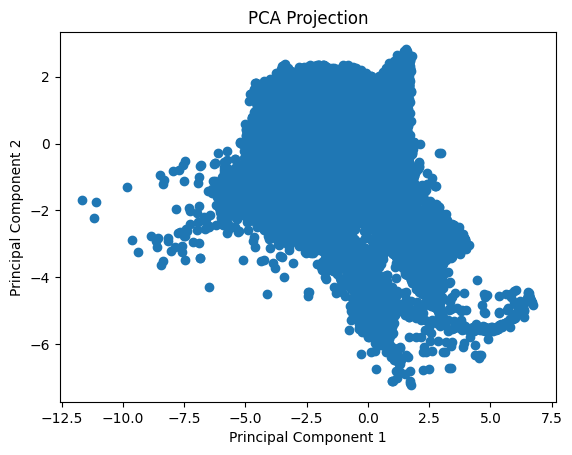

In [44]:
# Plot the PCA results
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection")
plt.show()

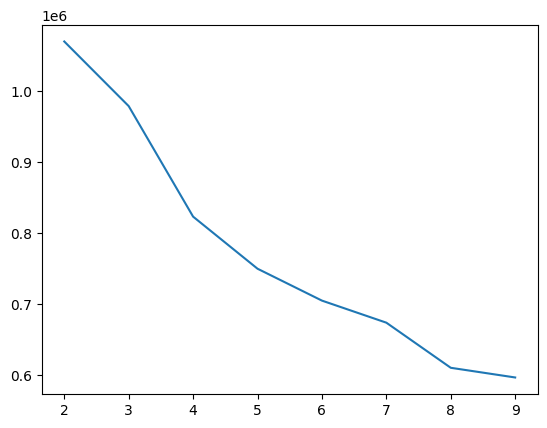

In [51]:
from sklearn.mixture import GaussianMixture 

bic = []
aic = []
K = range(2, 10)

for k in K:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_pca)
    bic.append(gmm.bic(X_pca))
    aic.append(gmm.aic(X_pca))

plt.plot(K,bic)

In [52]:
gmm = GaussianMixture(
    n_components=5,          # number of clusters
    covariance_type='full',  # usually best in PCA space
    random_state=22
)

labels = gmm.fit_predict(X_pca)

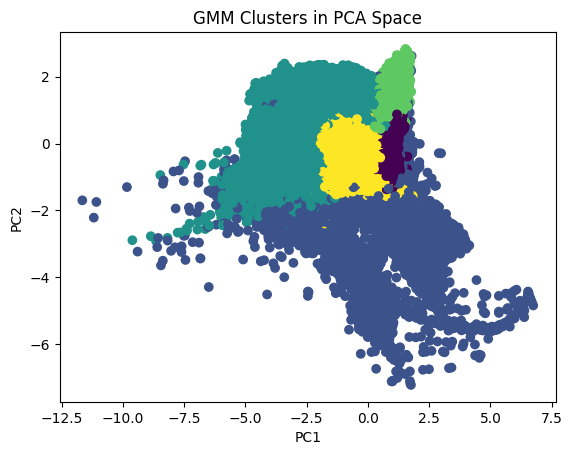

In [53]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("GMM Clusters in PCA Space")
plt.show()

In [54]:
df_sampled['gmm_label']=labels

In [55]:
import plotly.express as px
# Compute data centroid (mean location)
center_lat = df_sampled['Latitude_[deg_N]'].mean()
center_lon = df_sampled['Longitude_[deg_E]'].mean()

print("Center lat:", center_lat, "Center lon:", center_lon)

# Use labels from kmeans clustering on data to plot geographically
fig3 = px.scatter_geo(
    df_sampled,
    lat='Latitude_[deg_N]',
    lon='Longitude_[deg_E]',
    color='gmm_label',
    title="Gaussian Mixture Model on VAE latent space projected on geographic map"
)

fig3.update_geos(
    projection_type="orthographic",
    projection_rotation=dict(lat=center_lat, lon=center_lon),
    showcoastlines=True,
    showcountries=True
)

fig3.update_layout(height=800, width=800)
fig3.show()

Center lat: 79.81604592 Center lon: -50.949791180000005


In [56]:
import plotly.graph_objects as go
# Plot in depth at different latitudes
fig4 = go.Figure()
for label in df_sampled['gmm_label'].unique():
    df_subset = df_sampled[df_sampled['gmm_label'] == label]
    fig4.add_trace(go.Scatter3d(
        x=df_subset['Longitude_[deg_E]'],
        y=df_subset['Latitude_[deg_N]'],
        z=df_subset['Depth_[m]'],
        mode='markers',
        marker=dict(size=2),
        name=f'Cluster {label}'
    ))
fig4.update_layout(
    scene=dict(
        xaxis_title='Longitude',
        yaxis_title='Latitude',
        zaxis_title='Depth (m)',
        zaxis=dict(autorange='reversed')  # Depth increases downwards
    ),
    title="3D Scatter plot of GMM clusters in geographic space"
)
fig4.show()